# Jupyter Workflow Notebook (Sales Analysis)

## Business kontext

Tento notebook představuje strukturovaný a reprodukovatelný postup analýzy ukázkových prodejních dat.

## Zdroj dat

Analýza používá ukázkový CSV soubor s prodejními výsledky produktů podle regionů.

Zdrojová data jsou uložena ve složce `datasets/raw`. Původní soubor nebude během analýzy ručně upravován. Zjištěné problémy budou opraveny pomocí reprodukovatelných transformačních kroků.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

PROJECT_ROOT = Path.cwd().parents[1]
DATA_PATH = PROJECT_ROOT / "datasets" / "raw" / "sales.csv"

print(f"Datový soubor: {DATA_PATH.name}")
print(f"Soubor existuje: {DATA_PATH.exists()}")

Datový soubor: sales.csv
Soubor existuje: True


In [2]:
df_raw = pd.read_csv(DATA_PATH)

df_raw

,Produkt,Region,Revenue,Hodnocení
0,Sluchátka A,Praha,120000,4.6
1,myš B,brno,a85000,3.9
2,Klávesnice C,BRNO,60000,4.2
3,Monitor D,Ostrava,40000,2.8
4,Sluchátka A,praha,140000,4.7
5,Monitor D,ostrava,35000,2.5


## Validace dat

V této části ověříme strukturu, datové typy a kvalitu vstupních dat. Zjištěné problémy nejprve zdokumentujeme a teprve následně navrhneme jejich řešení.

In [3]:
print("Počet řádků:", df_raw.shape[0])
print("Počet sloupců:", df_raw.shape[1])
print("Názvy sloupců:", df_raw.columns.tolist())

df_raw.info()

Počet řádků: 6
Počet sloupců: 4
Názvy sloupců: ['Produkt', 'Region', 'Revenue', 'Hodnocení']
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Produkt    6 non-null      str    
 1   Region     6 non-null      str    
 2   Revenue    6 non-null      str    
 3   Hodnocení  6 non-null      float64
dtypes: float64(1), str(3)
memory usage: 324.0 bytes


In [4]:
print("Chybějící hodnoty:")
print(df_raw.isna().sum())

duplicate_count = df_raw.duplicated().sum()

print("Počet duplicitních řádků:", duplicate_count)

Chybějící hodnoty:
Produkt      0
Region       0
Revenue      0
Hodnocení    0
dtype: int64
Počet duplicitních řádků: 0


In [5]:
print("Unikátní produkty:")
print(df_raw["Produkt"].unique())

print("Unikátní regiony:")
print(df_raw["Region"].unique())

Unikátní produkty:
<StringArray>
['Sluchátka A', 'myš B', 'Klávesnice C', 'Monitor D']
Length: 4, dtype: str
Unikátní regiony:
<StringArray>
[' Praha', 'brno', 'BRNO', '  Ostrava', 'praha', 'ostrava']
Length: 6, dtype: str


In [6]:
revenue_numeric = pd.to_numeric(
    df_raw["Revenue"],
    errors="coerce"
)

invalid_revenue = df_raw[
    revenue_numeric.isna()
]

invalid_revenue

,Produkt,Region,Revenue,Hodnocení
1,myš B,brno,a85000,3.9


### Zjištění z validace dat

Validace identifikovala následující problémy:

- sloupec `Revenue` má textový datový typ místo číselného;
- hodnota `a85000` ve druhém datovém řádku není platné číslo;
- textové hodnoty obsahují nadbytečné mezery;
- názvy produktů a regionů používají nekonzistentní velikost písmen;
- dataset neobsahuje chybějící hodnoty;
- dataset neobsahuje přesné duplicitní řádky.

## Příprava a transformace dat

V této části vytvoříme pracovní kopii zdrojových dat a provedeme kroky potřebné k opravě identifikovaných problémů.

In [7]:
df = df_raw.copy()

### Standardizace textu

Z textových hodnot odstraníme nadbytečné mezery a sjednotíme velikost písmen. Tím zabráníme tomu, aby byly například hodnoty `Praha` a `praha` při analýze považovány za rozdílné regiony.

In [8]:
df["Produkt"] = (
    df["Produkt"]
    .str.strip()
    .str.title()
)

df["Region"] = (
    df["Region"]
    .str.strip()
    .str.title()
)

In [9]:
print("Unikátní produkty:")
print(df["Produkt"].unique())

print("Unikátní regiony:")
print(df["Region"].unique())

Unikátní produkty:
<StringArray>
['Sluchátka A', 'Myš B', 'Klávesnice C', 'Monitor D']
Length: 4, dtype: str
Unikátní regiony:
<StringArray>
['Praha', 'Brno', 'Ostrava']
Length: 3, dtype: str


#### Poznámka

Stejnou úpravu můžeme provést pro více textových sloupců pomocí `for` cyklu:

```python
text_columns = [
    "Produkt",
    "Region"
]

for column in text_columns:
    df[column] = (
        df[column]
        .str.strip()
        .str.title()
    )
```

### Oprava tržeb

Hodnota `a85000` byla při validaci identifikována jako překlep. V rámci ukázkového datasetu je známo, že správná hodnota je `85000`.

Nejprve opravíme konkrétní chybnou hodnotu a následně převedeme celý sloupec `Revenue` na číselný datový typ.

In [10]:
df["Revenue"] = (
    df["Revenue"]
    .replace("a85000", "85000")
    .astype(float)
)

In [11]:
print("Datové typy:")
print(df.dtypes)

print("Unikátní produkty:")
print(df["Produkt"].unique())

print("Unikátní regiony:")
print(df["Region"].unique())

print("Původní hodnota:", df_raw.loc[1, "Revenue"])
print("Opravená hodnota:", df.loc[1, "Revenue"])

df

Datové typy:
Produkt          str
Region           str
Revenue      float64
Hodnocení    float64
dtype: object
Unikátní produkty:
<StringArray>
['Sluchátka A', 'Myš B', 'Klávesnice C', 'Monitor D']
Length: 4, dtype: str
Unikátní regiony:
<StringArray>
['Praha', 'Brno', 'Ostrava']
Length: 3, dtype: str
Původní hodnota: a85000
Opravená hodnota: 85000.0


,Produkt,Region,Revenue,Hodnocení
0,Sluchátka A,Praha,120000.0,4.6
1,Myš B,Brno,85000.0,3.9
2,Klávesnice C,Brno,60000.0,4.2
3,Monitor D,Ostrava,40000.0,2.8
4,Sluchátka A,Praha,140000.0,4.7
5,Monitor D,Ostrava,35000.0,2.5


### Validace po čištění

Po provedení transformačních kroků znovu ověříme datové typy, chybějící hodnoty, duplicity a základní business pravidla.

In [12]:
print("Chybějící hodnoty:")
print(df.isna().sum())

print("Počet duplicitních řádků:")
print(df.duplicated().sum())

print("Datové typy:")
print(df.dtypes)

Chybějící hodnoty:
Produkt      0
Region       0
Revenue      0
Hodnocení    0
dtype: int64
Počet duplicitních řádků:
0
Datové typy:
Produkt          str
Region           str
Revenue      float64
Hodnocení    float64
dtype: object


### Validace business pravidel

Ověříme základní business pravidla pro číselné hodnoty:

- `Revenue` musí být větší než `0`;
- `Hodnocení` musí být v rozsahu od `0` do `5`.

Řádky, které některé pravidlo porušují, budou zobrazeny pro další kontrolu. Prázdný výsledek znamená, že žádný záznam definovaná pravidla neporušuje.

In [13]:
invalid_values = df[
    (df["Revenue"] <= 0)
    | (df["Hodnocení"] < 0)
    | (df["Hodnocení"] > 5)
]

invalid_values

,Produkt,Region,Revenue,Hodnocení


### Sumář z přípravy a transformace dat

Příprava dat zahrnovala:

- odstranění nadbytečných mezer v textových hodnotách;
- sjednocení velikosti písmen u produktů a regionů;
- opravu známého překlepu ve sloupci `Revenue`;
- převod `Revenue` na číselný datový typ;
- opakovanou kontrolu chybějících hodnot a duplicit;
- ověření základních business pravidel.

Vyčištěný a transformovaný dataset je připravený pro analýzu.

## Analýza dat

Analýza se zaměří na následující otázky:

1. Jaké jsou celkové tržby?
2. Jaké je průměrné hodnocení?
3. Které regiony vytvářejí nejvyšší tržby?
4. Které produkty vytvářejí nejvyšší tržby?
5. Jak se liší průměrné hodnocení produktů?

### Celkový pohled

In [14]:
total_revenue = df["Revenue"].sum()
average_rating = df["Hodnocení"].mean()

print("Celkové tržby:", total_revenue, "Kč")
print("Průměrné hodnocení:", round(average_rating, 2))

Celkové tržby: 480000.0 Kč
Průměrné hodnocení: 3.78


### Základní zjištění

Celkové tržby v analyzovaném vzorku činí `480 000 Kč` a průměrné hodnocení produktů dosahuje hodnoty `3,78` z `5`.

Samotné celkové ukazatele nestačí k posouzení výkonnosti jednotlivých regionů a produktů. V další části proto výsledky rozdělíme podle těchto kategorií.

### Regiony

In [15]:
record_count=("Region", "size")

region_summary = (
    df.groupby(
        "Region",
        as_index=False
    )
    .agg(
        total_revenue=("Revenue", "sum"),
        average_rating=("Hodnocení", "mean"),
        record_count=("Region", "size")
    )
    .sort_values(
        by="total_revenue",
        ascending=False,
        ignore_index=True
    )
)


region_summary

,Region,total_revenue,average_rating,record_count
0,Praha,260000.0,4.65,2
1,Brno,145000.0,4.05,2
2,Ostrava,75000.0,2.65,2


### Regionální zjištění

Praha dosahuje nejvyšších tržeb i nejvyššího průměrného hodnocení. Brno se umístilo na druhém místě a Ostrava vykazuje nejnižší tržby i hodnocení.

Výsledky je nutné interpretovat opatrně:
- každý region obsahuje pouze dva záznamy;
- oba záznamy z Ostravy se týkají produktu Monitor D;
- z dostupných dat proto nelze oddělit vliv regionu od vlivu produktového zastoupení;
- závěry jsou orientační a nelze je zobecnit na celkovou výkonnost regionů.

### Produkty

In [16]:
product_summary = (
    df.groupby(
        "Produkt",
        as_index=False
    )
    .agg(
        total_revenue=("Revenue", "sum"),
        average_rating=("Hodnocení", "mean"),
        record_count=("Produkt", "size")
    )
    .sort_values(
        by="total_revenue",
        ascending=False,
        ignore_index=True
    )
)

product_summary

,Produkt,total_revenue,average_rating,record_count
0,Sluchátka A,260000.0,4.65,2
1,Myš B,85000.0,3.90,1
2,Monitor D,75000.0,2.65,2
3,Klávesnice C,60000.0,4.20,1


### Produktová zjištění

- Nejvyšší celkové tržby mají **Sluchátka A**: 260 000.
- Sluchátka A mají současně nejvyšší průměrné hodnocení: 4,65.
- Nejnižší průměrné hodnocení má **Monitor D**: 2,65.
- Monitor D má zároveň poměrně nízké celkové tržby: 75 000.
- Klávesnice C má nejnižší celkové tržby, ale její hodnocení je poměrně vysoké.
- Výsledky produktů vycházejí pouze z jednoho nebo dvou záznamů, proto je nelze zobecňovat.

Samotný produktový pohled nevysvětluje regionální rozdíly, protože neukazuje, ve kterých regionech byly jednotlivé produkty prodávány. Pro posouzení vztahu mezi produktem a regionem je potřeba společný pohled podle regionu a produktu.

### Regiony vs produkty

In [17]:
region_product_summary = (
    df.groupby(
        ["Region", "Produkt"],
        as_index=False
    )
    .agg(
        total_revenue=("Revenue", "sum"),
        average_rating=("Hodnocení", "mean"),
        record_count=("Produkt", "size")
    )
    .sort_values(
        by=["Region", "total_revenue"],
        ascending=[True, False],
        ignore_index=True
    )
)

region_product_summary

,Region,Produkt,total_revenue,average_rating,record_count
0,Brno,Myš B,85000.0,3.90,1
1,Brno,Klávesnice C,60000.0,4.20,1
2,Ostrava,Monitor D,75000.0,2.65,2
3,Praha,Sluchátka A,260000.0,4.65,2


### Regiony vs produkty zjištění

- Výsledky Ostravy jsou tvořeny pouze produktem Monitor D.
- Monitor D má nízké celkové tržby i nejnižší průměrné hodnocení.
- Data naznačují, že slabší výsledky Ostravy mohou souviset spíše s produktem než se samotným regionem.
- Tento předpoklad však nelze potvrdit, protože Monitor D není zastoupen v jiných regionech.
- Pro oddělení vlivu produktu a regionu by bylo nutné porovnat stejné produkty napříč více regiony.
- Závěry jsou pouze orientační kvůli velmi malému počtu záznamů.

### Vizualizace - tržby po produktech

Graf porovnává celkové tržby jednotlivých produktů. Slouží k rychlé identifikaci produktů s nejvyšším a nejnižším příspěvkem k tržbám.

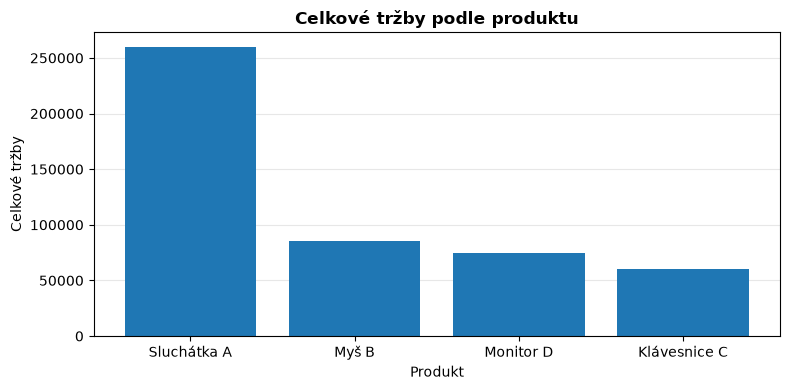

In [18]:
plt.figure(figsize=(8, 4))

plt.bar(
    product_summary["Produkt"],
    product_summary["total_revenue"]
)

plt.title(
    "Celkové tržby podle produktu",
    fontweight="bold"
)

plt.xlabel("Produkt")
plt.ylabel("Celkové tržby")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

### Vizualizace - hodnocení produktů

Graf porovnává průměrné hodnocení jednotlivých produktů. Hodnocení je zobrazeno na jednotné škále od 0 do 5.

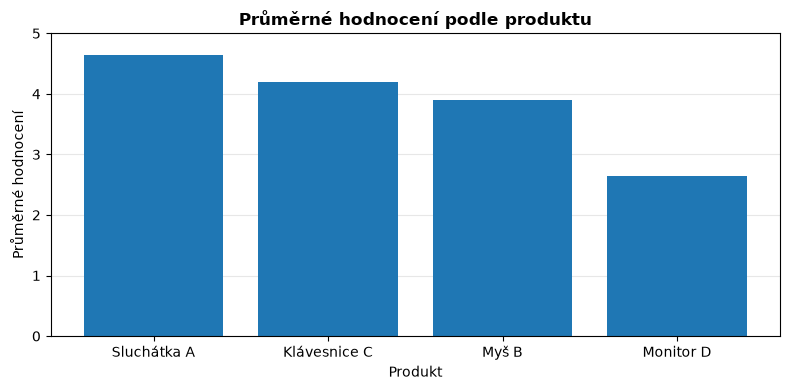

In [19]:
rating_summary = product_summary.sort_values(
    by="average_rating",
    ascending=False,
    ignore_index=True
)

plt.figure(figsize=(8, 4))

plt.bar(
    rating_summary["Produkt"],
    rating_summary["average_rating"]
)

plt.title(
    "Průměrné hodnocení podle produktu",
    fontweight="bold"
)

plt.xlabel("Produkt")
plt.ylabel("Průměrné hodnocení")

plt.ylim(0, 5)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

## Souhrnná zjištění

- Celkové tržby analyzovaného datasetu činí 480 000.
- Nejvyšší tržby vytváří produkt Sluchátka A, který má zároveň nejvyšší průměrné hodnocení.
- Monitor D má nízké tržby a nejnižší průměrné hodnocení.
- Praha dosahuje nejvyšších tržeb i nejvyššího průměrného hodnocení.
- Slabší výsledky Ostravy jsou tvořeny pouze produktem Monitor D.
- Data naznačují možný problém spojený s produktem Monitor D, ale neumožňují oddělit vliv produktu od vlivu regionu.

## Omezení

- Dataset obsahuje pouze šest záznamů, takže výsledky nelze zobecňovat.
- Některé produkty jsou zastoupeny pouze jedním záznamem.
- Jednotlivé produkty nejsou prodávány ve více regionech, proto nelze oddělit vliv produktu od vlivu regionu.
- Dataset neobsahuje časové údaje, takže nelze analyzovat vývoj tržeb ani hodnocení v čase.
- Nejsou k dispozici informace o počtu prodaných kusů, cenách, nákladech ani zákaznících.
- Hodnota Revenue byla u jednoho záznamu opravena podle zjevné textové chyby ve zdrojových datech.

## Doporučení

- Prověřit možné příčiny nízkého hodnocení produktu Monitor D, například pomocí zákaznických recenzí nebo reklamací.
- Nerozhodovat o omezení produktu pouze na základě tohoto malého datasetu.
- Získat větší počet záznamů za delší časové období.
- Zajistit, aby bylo možné porovnat stejné produkty napříč více regiony.
- Doplnit počet prodaných kusů, cenu, náklady a datum prodeje, aby bylo možné provést podrobnější obchodní analýzu.
- Nastavit při načítání dat kontrolu datových typů a neplatných hodnot ve sloupci Revenue.

## Export čistých dat

Vyčištěný a validovaný dataset ukládáme odděleně od původních dat. Zdrojový soubor ve složce raw zůstává zachován beze změny.

In [20]:
OUTPUT_PATH = (
    PROJECT_ROOT
    / "datasets"
    / "processed"
    / "sales_clean.csv"
)

OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

df.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding="utf-8"
)

print("Soubor byl uložen:", OUTPUT_PATH.name)
print("Soubor existuje:", OUTPUT_PATH.exists())

Soubor byl uložen: sales_clean.csv
Soubor existuje: True


## KONEC